In [1]:
%matplotlib inline
import os
import re
from collections import defaultdict
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#result_dir = 'gnr_aws/deepseek-ai--DeepSeek-R1-Distill-Llama-8B'
result_dir = 'spr_aws_c1'
#csv_file = 'gnr_aws/result_v1_spr_full_sys_sweep.csv'

In [3]:
group1 = ['Llama-3.2-1B', 'DeepSeek-R1-Distill-Qwen-1.5B', 'Llama-3.2-3B-Instruct']
group2 = ['Llama-2-7b-chat-hf', 'Llama-3.1-8B-Instruct', 'DeepSeek-R1-Distill-Llama-8B']
group3 = ['Llama-2-13b-chat-hf', 'DeepSeek-R1-Distill-Qwen-14B']

In [4]:
def get_json(fn):
    j = None
    try:
        with open(fn, 'r') as f:
            j = json.load(f)
    except Exception as e:
        print(f"Opening file {fn} failed with exception {e}")
        #sys.exit(1)
    return j

def get_result_files(directory):
    all_files = defaultdict(list)
    for root, dirs, files in os.walk(directory):
        for file in files:
            r = root[len(directory)+1:].split('/')
            c = file.split('-')[1]
            key = f"{r[0].split('--')[1]}+{r[1]}+{c}"
            all_files[key].append(os.path.join(root, file))            
    return all_files

def extract_results_from_json(fn):
    j = get_json(fn)
    return {
        'Model': j['model_id'],
        'Input Tokens': int(j['total_input_tokens']/j['num_prompts']),
        'Output Tokens': int(j['total_output_tokens']/j['num_prompts']),
        'Concurrency': int(j['request_rate']),
        'Output tput (tokens/sec)': round(j['output_throughput'], 2),
        'Total tput (tokens/sec)': round(j['total_token_throughput'], 2),
        'TTFT avg (ms)': round(j['mean_ttft_ms'], 2),
        'TTFT P50 (ms)': round(j['p50_ttft_ms'], 2),
        'TTFT P90 (ms)': round(j['p90_ttft_ms'], 2),
        'TTFT P99 (ms)': round(j['p99_ttft_ms'], 2),
        'TPOT avg (ms)': round(j['mean_tpot_ms'], 2),
        'TPOT P50 (ms)': round(j['p50_tpot_ms'], 2),
        'TPOT P90 (ms)': round(j['p90_tpot_ms'], 2),
        'TPOT P99 (ms)': round(j['p99_tpot_ms'], 2),
        'Request Throughput': round(j['request_throughput'], 2),
        'Request Latency avg (s)': round(j['mean_e2el_ms']/1000, 2),
        'Request Latency P50 (s)': round(j['p50_e2el_ms']/1000, 2),
        'Request Latency P90 (s)': round(j['p90_e2el_ms']/1000, 2),
        'Request Latency P99 (s)': round(j['p99_e2el_ms']/1000, 2),
    }

In [5]:
files = get_result_files(result_dir)

In [6]:
dfs = dict()
for k in files:
    values = []
    for f in files[k]:
        values.append(extract_results_from_json(f))
    dfs[k] = pd.DataFrame(values)
    dfs[k] = dfs[k].iloc[1:]

In [7]:
#model = 'DeepSeek-R1-Distill-Qwen-14B'
model = 'DeepSeek-R1-Distill-Qwen-1.5B'
#model = 'Llama-3.2-1B'

#IO = 'I100-O300+C1'
IO = 'I1000-O1000+C1'
#IO = 'I10000-O1500+C1'
#IO = 'I1000-O1000+C10'

dfs[model+'+'+IO]

,Model,Input Tokens,Output Tokens,Concurrency,Output tput (tokens/sec),Total tput (tokens/sec),TTFT avg (ms),TTFT P50 (ms),TTFT P90 (ms),TTFT P99 (ms),TPOT avg (ms),TPOT P50 (ms),TPOT P90 (ms),TPOT P99 (ms),Request Throughput,Request Latency avg (s),Request Latency P50 (s),Request Latency P90 (s),Request Latency P99 (s)
1,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.63,75.25,41.17,41.17,41.17,41.17,26.56,26.56,26.56,26.56,0.04,26.58,26.58,26.58,26.58
2,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.70,75.40,41.37,41.37,41.37,41.37,26.51,26.51,26.51,26.51,0.04,26.52,26.52,26.52,26.52
3,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.71,75.42,41.15,41.15,41.15,41.15,26.50,26.50,26.50,26.50,0.04,26.52,26.52,26.52,26.52
4,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.75,75.49,41.38,41.38,41.38,41.38,26.48,26.48,26.48,26.48,0.04,26.49,26.49,26.49,26.49
5,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.69,75.38,41.10,41.10,41.10,41.10,26.52,26.52,26.52,26.52,0.04,26.53,26.53,26.53,26.53
6,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.63,75.27,41.46,41.46,41.46,41.46,26.56,26.56,26.56,26.56,0.04,26.57,26.57,26.57,26.57
7,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.47,74.94,41.47,41.47,41.47,41.47,26.67,26.67,26.67,26.67,0.04,26.69,26.69,26.69,26.69
8,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.65,75.31,41.18,41.18,41.18,41.18,26.54,26.54,26.54,26.54,0.04,26.56,26.56,26.56,26.56
9,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,1000,1000,1,37.58,75.16,41.11,41.11,41.11,41.11,26.59,26.59,26.59,26.59,0.04,26.61,26.61,26.61,26.61


In [8]:
def get_plot_df(models, io, col, c):
    d = defaultdict(list)
    for m in models:
        d[m] += (dfs[f"{m}+{io}+{c}"][col].tolist())
    df = pd.DataFrame(d)
    df.index = np.arange(1, len(df) + 1)
    return df


def create_box_plot(df, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(12, 6))
    df.boxplot()
    plt.tight_layout()
    plt.show()


def create_line_plot(df, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(12, 3))
    df.plot.line(
        ax=ax,
        style='o-',  # Circle markers 
        linewidth=2,
        markersize=8,
        #color=['navy', 'crimson'],
        title=title
    )
    ax.set_ylim(bottom=0, top=max(df.max())+20)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    # Remove all borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='#EEEEEE', linestyle='--', linewidth=0.8, zorder=0)
    ax.xaxis.grid(True, color='#EEEEEE', linestyle='--', linewidth=0.8, zorder=0)
    
    # Place legend at the rightmost corner
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves legend outside plot area[8]
    
    plt.tight_layout()
    plt.show()


def create_grouped_bar_graph(data, group_labels, bar_labels, title, xlabel, ylabel):
    num_groups = len(data)
    num_bars = len(data[0])
    
    #fig, ax = plt.subplots(figsize=(10, 4))
    fig, ax = plt.subplots(figsize=(12, 3))
    
    index = np.arange(num_bars)
    #bar_width = 0.8 / num_groups
    bar_width = 0.4 / num_groups
    opacity = 0.8
    
    for i in range(num_groups):
        ax.bar(index + i * bar_width, data[i], bar_width,
               alpha=opacity, label=group_labels[i])
    
    ax.set_xlabel(xlabel, fontweight='bold', fontsize=12, labelpad=10)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=12, labelpad=10)
    ax.set_title(title, fontweight='bold', fontsize=16, pad=20)
    ax.set_xticks(index + bar_width * (num_groups - 1) / 2)
    #ax.set_xticklabels(bar_labels, rotation=25, ha='right')
    ax.set_xticklabels(bar_labels, rotation=0, ha='center')
    
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='#EEEEEE', linestyle='--', linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)
    
    for i, group in enumerate(data):
        for j, value in enumerate(group):
            if value != 0:
                #ax.text(j + i * bar_width, value, f'{value}', ha='center', va='bottom', fontweight='bold', fontsize=10)
                ax.text(j + i * bar_width, value, f'{value}', ha='center', va='bottom', fontsize=7)
            else:
                ax.text(j + i * bar_width, value, '', ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.show()


def op_grouped_bars(models, col, c, ti, xl, yl):
    group_labels_c2 = ['100 input tokens', '1k input tokens', '10k input tokens']
    group_labels_c20 = ['1k input tokens']
    bar_labels = models
    title = ti
    xlabel = xl
    ylabel = yl
    
    if c == 'C1' or c == 'C1':
        data = [[] for _ in range(3)]
        for m in models:
            data[0].append(dfs[f"{m}+I100-O300+{c}"][col].median())
            data[1].append(dfs[f"{m}+I1000-O1000+{c}"][col].median())
            if f"{m}+I10000-O1500+C1" in dfs:
                data[2].append(dfs[f"{m}+I10000-O1500+{c}"][col].median())
            else:
                data[2].append(0)
        create_grouped_bar_graph(data, group_labels_c2, bar_labels, title, xlabel, ylabel)
    else:
        data = [[] for _ in range(1)]
        for m in models:
            data[0].append(dfs[f"{m}+I1000-O1000+{c}"][col].median())
        create_grouped_bar_graph(data, group_labels_c20, bar_labels, title, xlabel, ylabel)



# C1 C10

## Output speed by input token count

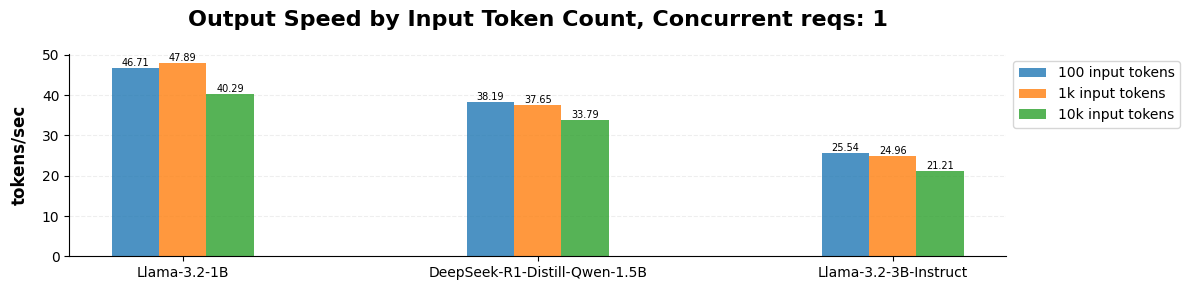

In [9]:
op_grouped_bars(group1, 'Output tput (tokens/sec)', 'C1', 'Output Speed by Input Token Count, Concurrent reqs: 1', '', 'tokens/sec')

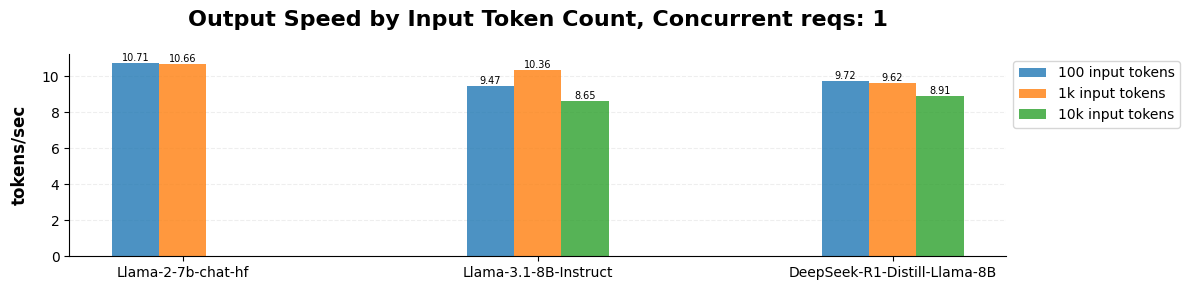

In [10]:
op_grouped_bars(group2, 'Output tput (tokens/sec)', 'C1', 'Output Speed by Input Token Count, Concurrent reqs: 1', '', 'tokens/sec')

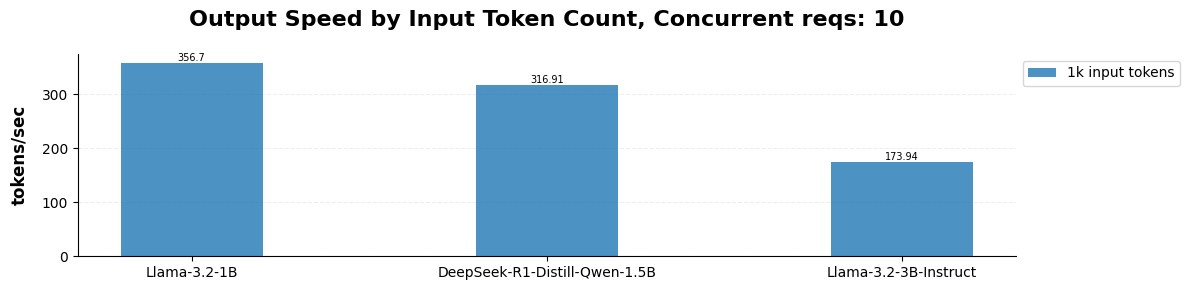

In [11]:
op_grouped_bars(group1, 'Output tput (tokens/sec)', 'C10', 'Output Speed by Input Token Count, Concurrent reqs: 10', '', 'tokens/sec')

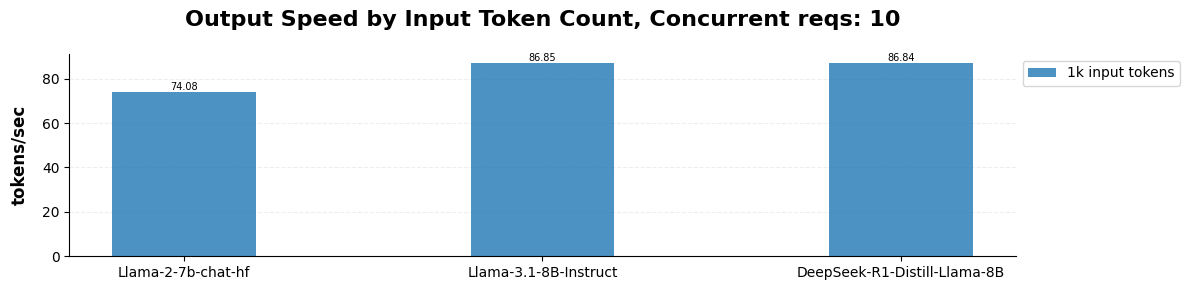

In [12]:
op_grouped_bars(group2, 'Output tput (tokens/sec)', 'C10', 'Output Speed by Input Token Count, Concurrent reqs: 10', '', 'tokens/sec')

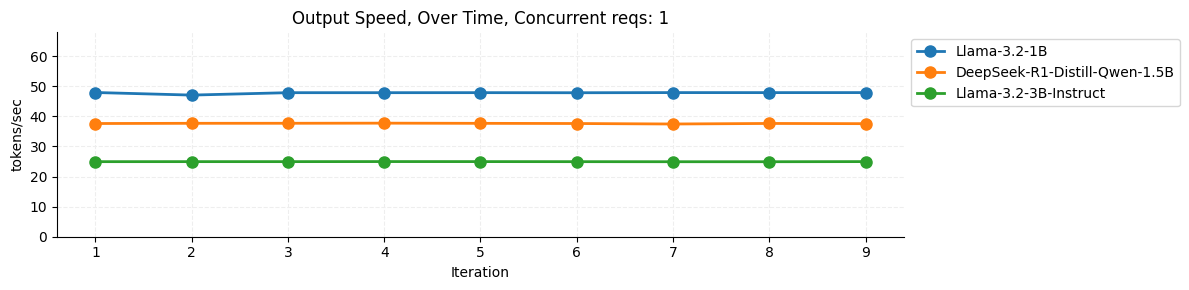

In [13]:
df = get_plot_df(group1, 'I1000-O1000', 'Output tput (tokens/sec)', 'C1')
#create_box_plot(df, 'Output Speed Variance', '', 'tokens/sec')
create_line_plot(df, 'Output Speed, Over Time, Concurrent reqs: 1', 'Iteration', 'tokens/sec')

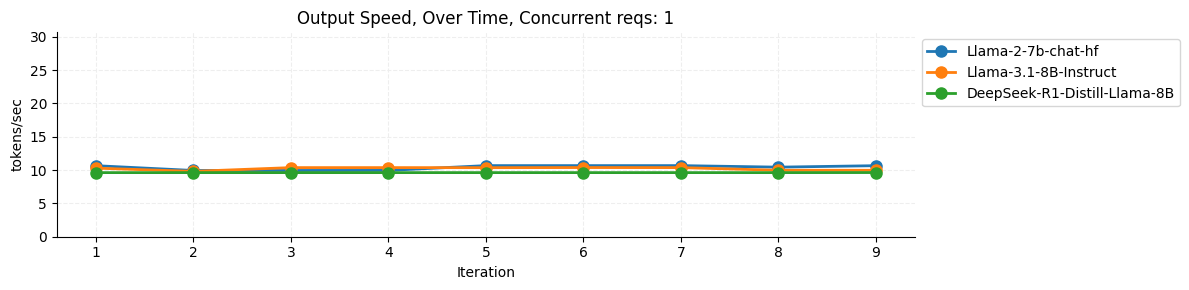

In [14]:
df = get_plot_df(group2, 'I1000-O1000', 'Output tput (tokens/sec)', 'C1')
create_line_plot(df, 'Output Speed, Over Time, Concurrent reqs: 1', 'Iteration', 'tokens/sec')

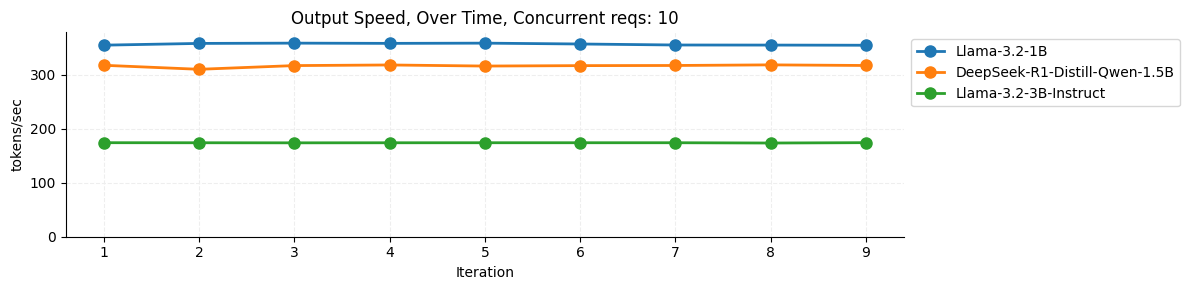

In [15]:
df = get_plot_df(group1, 'I1000-O1000', 'Output tput (tokens/sec)', 'C10')
create_line_plot(df, 'Output Speed, Over Time, Concurrent reqs: 10', 'Iteration', 'tokens/sec')

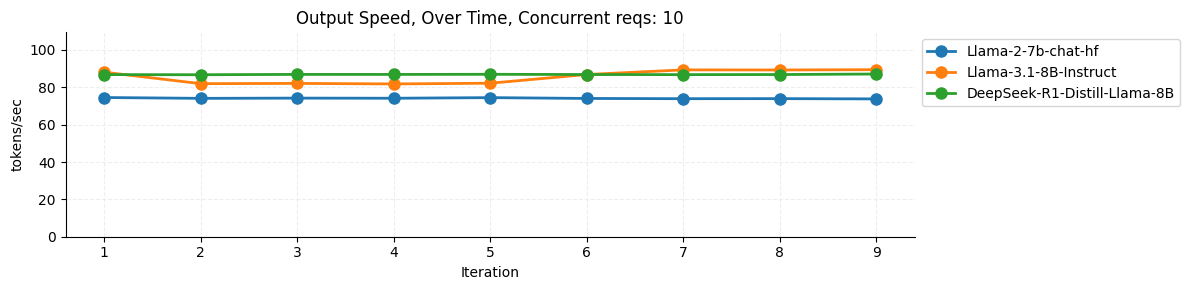

In [16]:
df = get_plot_df(group2, 'I1000-O1000', 'Output tput (tokens/sec)', 'C10')
create_line_plot(df, 'Output Speed, Over Time, Concurrent reqs: 10', 'Iteration', 'tokens/sec')

## Time to First Token by Input Token Count

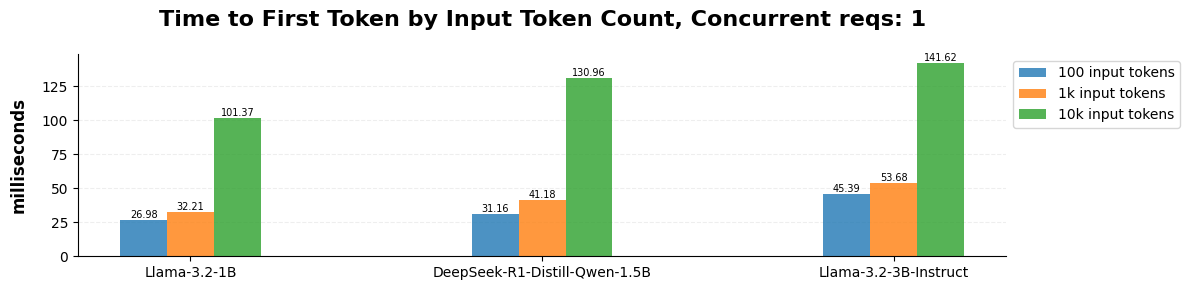

In [17]:
op_grouped_bars(group1, 'TTFT P50 (ms)', 'C1', 'Time to First Token by Input Token Count, Concurrent reqs: 1', '', 'milliseconds')

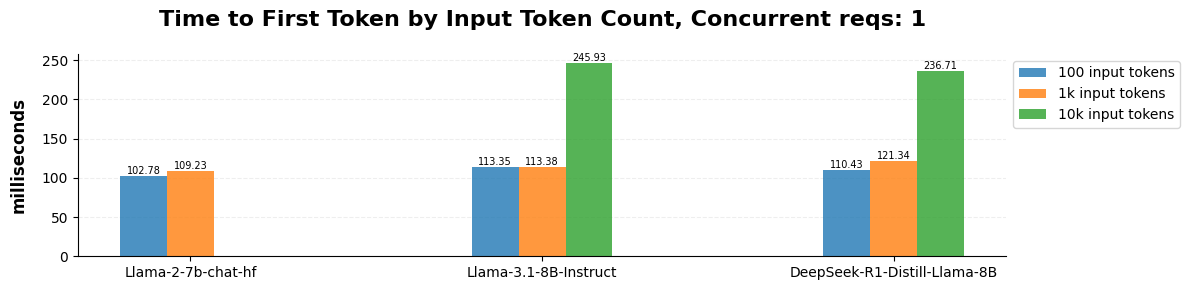

In [18]:
op_grouped_bars(group2, 'TTFT P50 (ms)', 'C1', 'Time to First Token by Input Token Count, Concurrent reqs: 1', '', 'milliseconds')

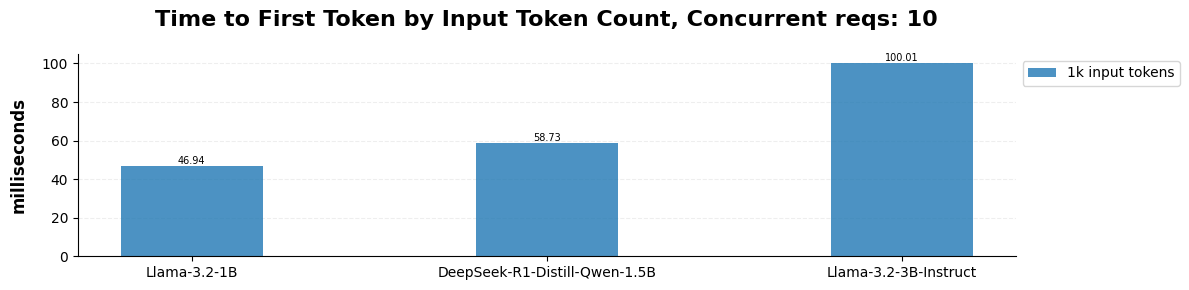

In [19]:
op_grouped_bars(group1, 'TTFT P50 (ms)', 'C10', 'Time to First Token by Input Token Count, Concurrent reqs: 10', '', 'milliseconds')

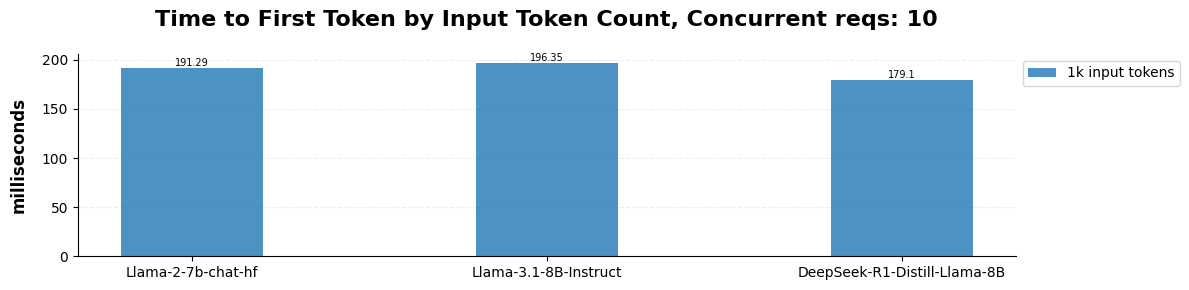

In [20]:
op_grouped_bars(group2, 'TTFT P50 (ms)', 'C10', 'Time to First Token by Input Token Count, Concurrent reqs: 10', '', 'milliseconds')

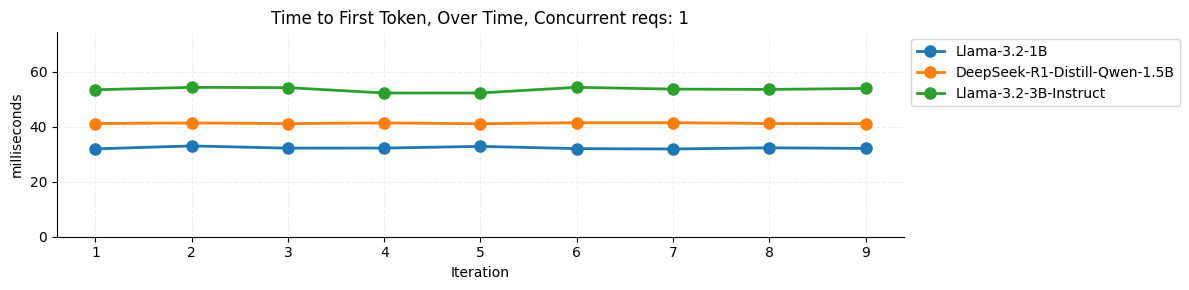

In [21]:
df = get_plot_df(group1, 'I1000-O1000', 'TTFT P50 (ms)', 'C1')
create_line_plot(df, 'Time to First Token, Over Time, Concurrent reqs: 1', 'Iteration', 'milliseconds')

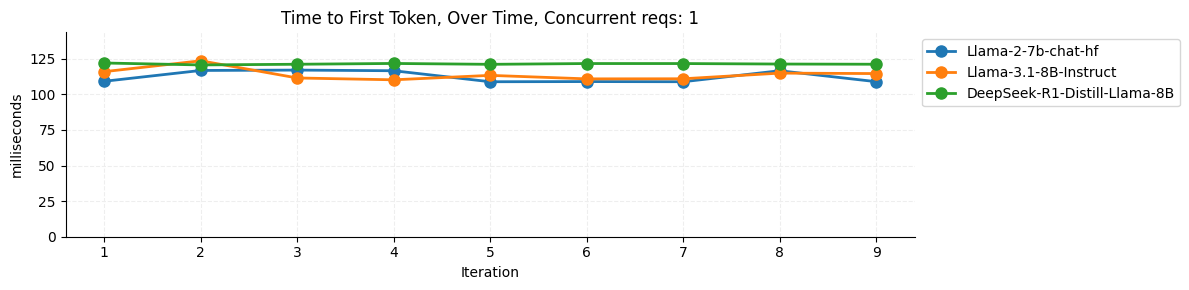

In [22]:
df = get_plot_df(group2, 'I1000-O1000', 'TTFT P50 (ms)', 'C1')
create_line_plot(df, 'Time to First Token, Over Time, Concurrent reqs: 1', 'Iteration', 'milliseconds')

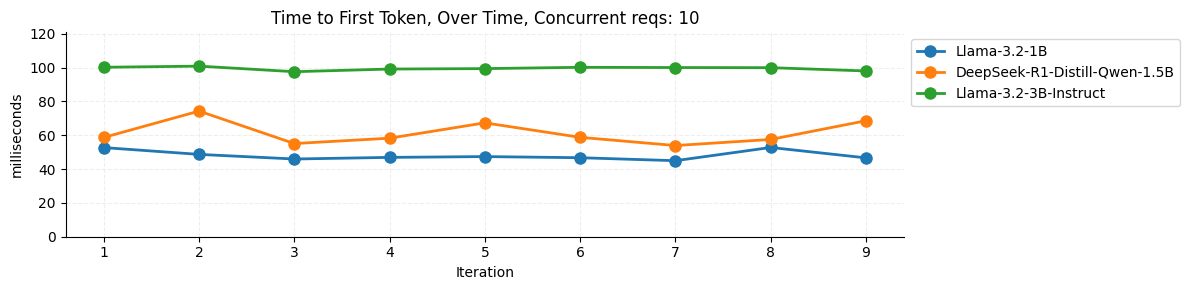

In [23]:
df = get_plot_df(group1, 'I1000-O1000', 'TTFT P50 (ms)', 'C10')
create_line_plot(df, 'Time to First Token, Over Time, Concurrent reqs: 10', 'Iteration', 'milliseconds')

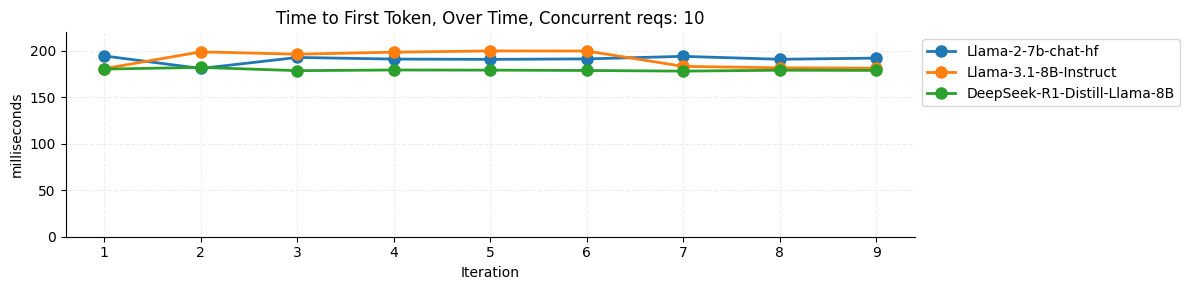

In [24]:
df = get_plot_df(group2, 'I1000-O1000', 'TTFT P50 (ms)', 'C10')
create_line_plot(df, 'Time to First Token, Over Time, Concurrent reqs: 10', 'Iteration', 'milliseconds')

## End-to-End Response Time by Input Token Count

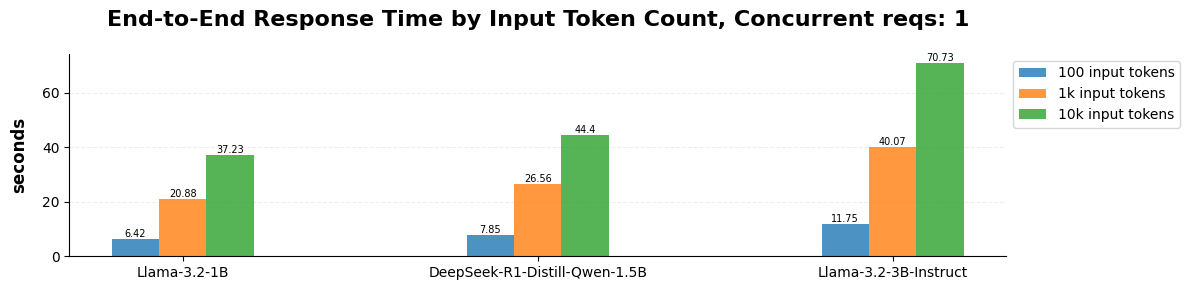

In [25]:
op_grouped_bars(group1, 'Request Latency P50 (s)', 'C1', 'End-to-End Response Time by Input Token Count, Concurrent reqs: 1', '', 'seconds')

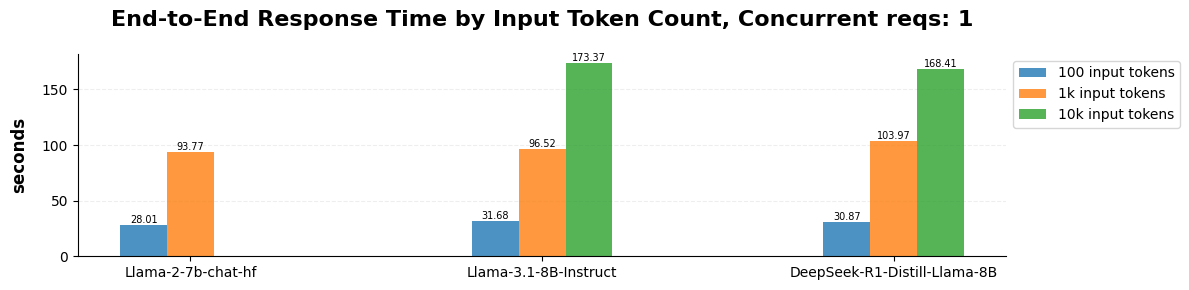

In [26]:
op_grouped_bars(group2, 'Request Latency P50 (s)', 'C1', 'End-to-End Response Time by Input Token Count, Concurrent reqs: 1', '', 'seconds')

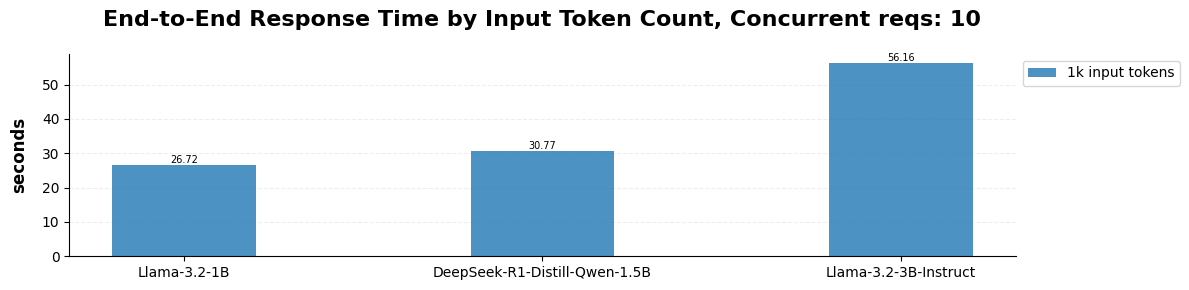

In [27]:
op_grouped_bars(group1, 'Request Latency P50 (s)', 'C10', 'End-to-End Response Time by Input Token Count, Concurrent reqs: 10', '', 'seconds')

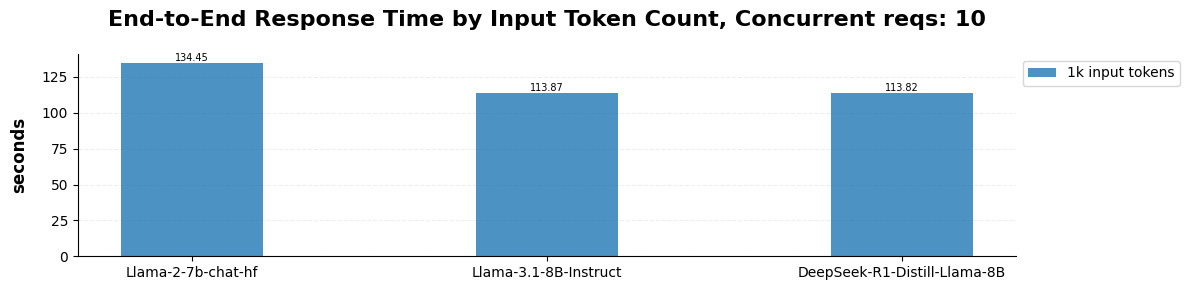

In [28]:
op_grouped_bars(group2, 'Request Latency P50 (s)', 'C10', 'End-to-End Response Time by Input Token Count, Concurrent reqs: 10', '', 'seconds')

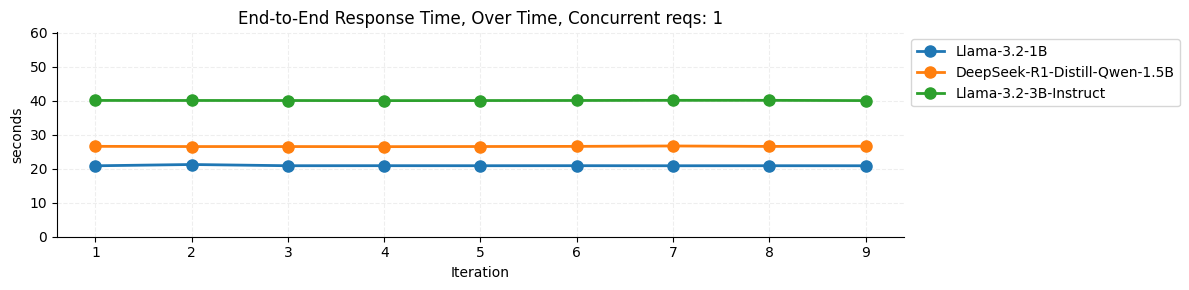

In [29]:
df = get_plot_df(group1, 'I1000-O1000', 'Request Latency P50 (s)', 'C1')
create_line_plot(df, 'End-to-End Response Time, Over Time, Concurrent reqs: 1', 'Iteration', 'seconds')

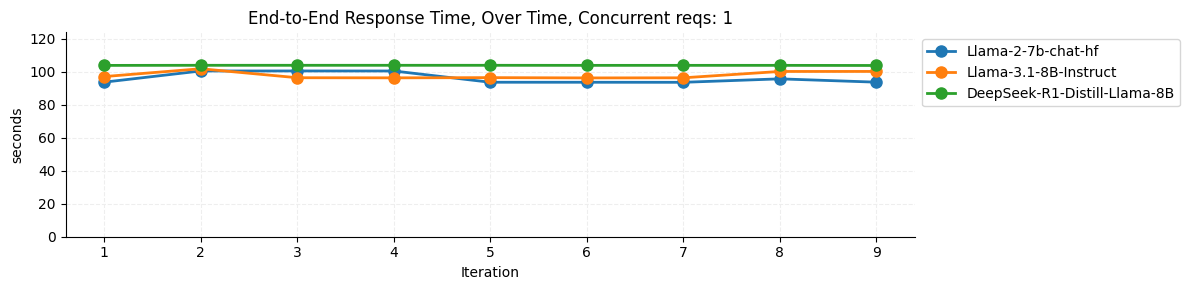

In [30]:
df = get_plot_df(group2, 'I1000-O1000', 'Request Latency P50 (s)', 'C1')
create_line_plot(df, 'End-to-End Response Time, Over Time, Concurrent reqs: 1', 'Iteration', 'seconds')

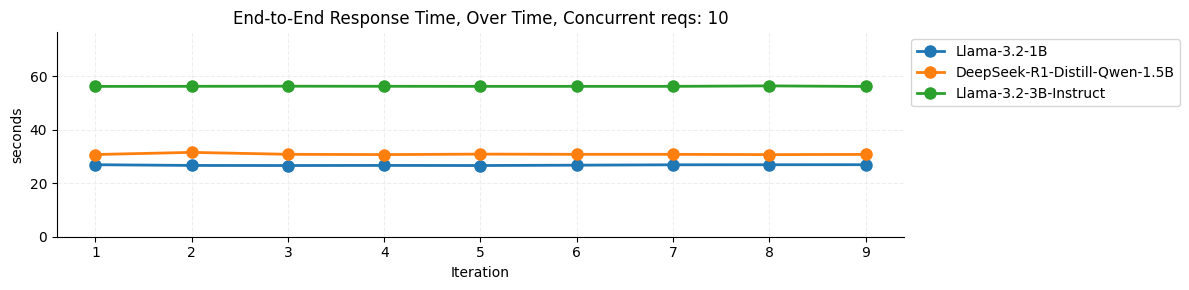

In [31]:
df = get_plot_df(group1, 'I1000-O1000', 'Request Latency P50 (s)', 'C10')
create_line_plot(df, 'End-to-End Response Time, Over Time, Concurrent reqs: 10', 'Iteration', 'seconds')

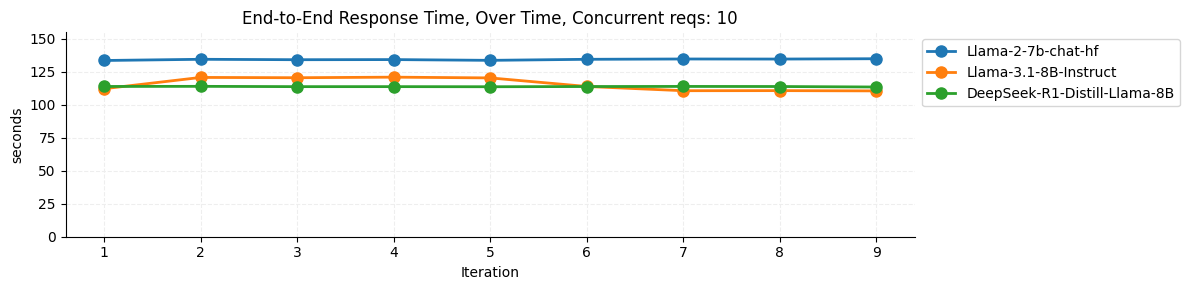

In [32]:
df = get_plot_df(group2, 'I1000-O1000', 'Request Latency P50 (s)', 'C10')
create_line_plot(df, 'End-to-End Response Time, Over Time, Concurrent reqs: 10', 'Iteration', 'seconds')